In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO BOILER → AC OPPORTUNITY CUSTOMERS
print("\n🎯 FILTERING TO BOILER → AC OPPORTUNITY")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get customers with boiler
has_boiler = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Chaudière' in x.values
)

# Get customers with AC
has_ac = df_quotes.groupby('numero_compte')['famille_equipement_produit'].apply(
    lambda x: 'Climatisation' in x.values
)

# Boiler → AC opportunity: has boiler, no AC
boiler_to_ac_ids = has_boiler[has_boiler & (~has_ac)].index.tolist()

# Filter data
df_quotes_boiler_ac = df_quotes[df_quotes['numero_compte'].isin(boiler_to_ac_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"Boiler → AC opportunity: {len(boiler_to_ac_ids):,} customers")
print(f"Quotes: {len(df_quotes_boiler_ac):,}")

# Save to file
df_quotes_boiler_ac.to_csv('cleaned_quote_data_boiler_ac.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_boiler_ac.csv")


🎯 FILTERING TO BOILER → AC OPPORTUNITY
Original customers: 25,716
Boiler → AC opportunity: 7,981 customers
Quotes: 11,181

✅ Saved to cleaned_quote_data_boiler_ac.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_boiler_ac.csv')


📊 Original quote data: 11,181 quotes from 7,981 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 7,981, Quotes: 11,058
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 7,981 customers | 42.0% converters
⏱️  Execution time: 3.3 seconds
⚠️  3.3s (target was 3s)
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 7,981
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/7,981 customers
  Processed 5,000/7,981 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 7,981
   First converters: 3,355 (42.0%)
   Never converters: 4,626

📊 Distribution check:
   Converters with 0 historical quotes: 2,550
   Non-converters with 0 historical quotes: 3,382
   Avg historical quotes - Converters: 0.3
   Avg histori

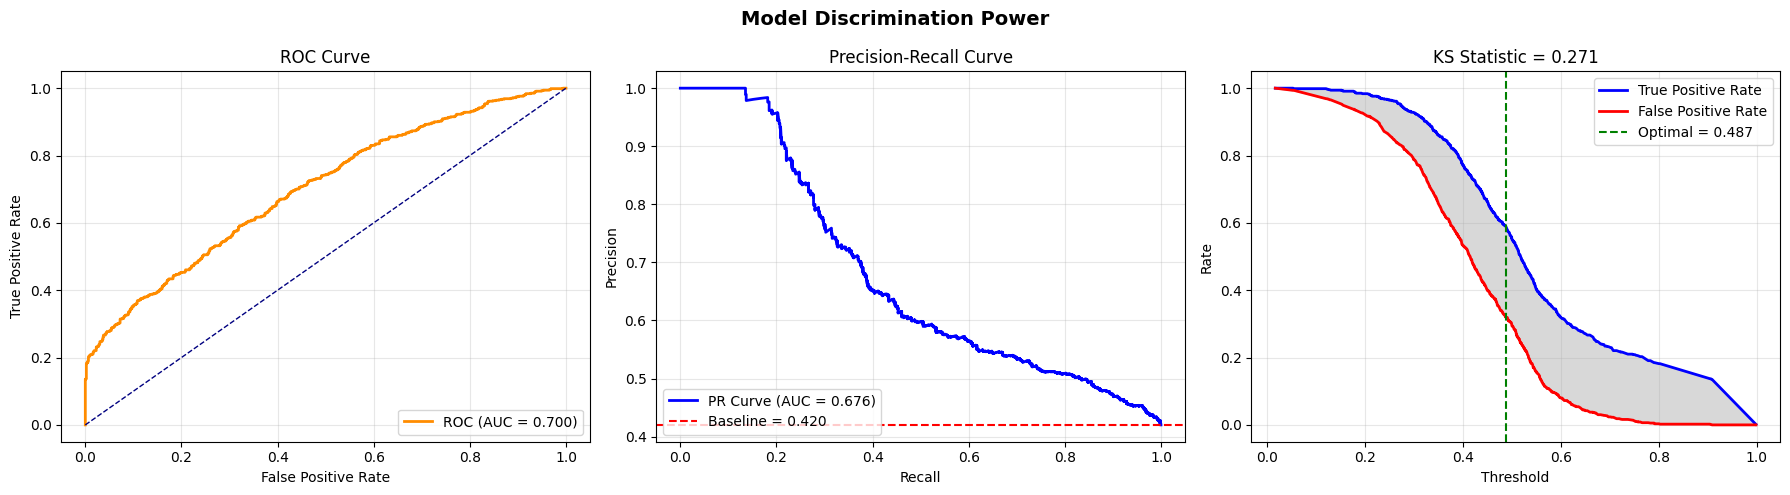

• ROC-AUC: 0.6996
• PR-AUC: 0.6758
• KS Statistic: 0.271 (WEAK discrimination)
• Optimal Threshold: 0.487

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.911
Decile 10 mean prob: 0.180


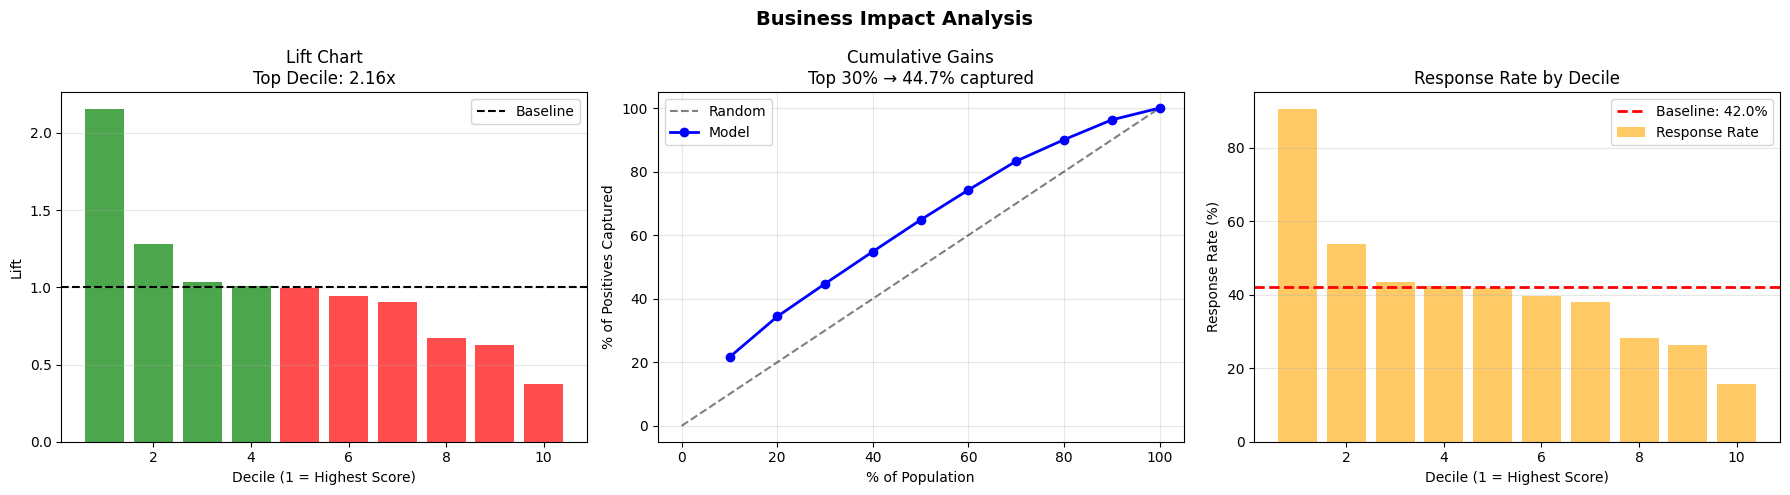

• Top Decile Lift: 0.37x
• Top 30% captures: 44.7% of positives
• Baseline response rate: 42.0%
• Top decile response: 90.6%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


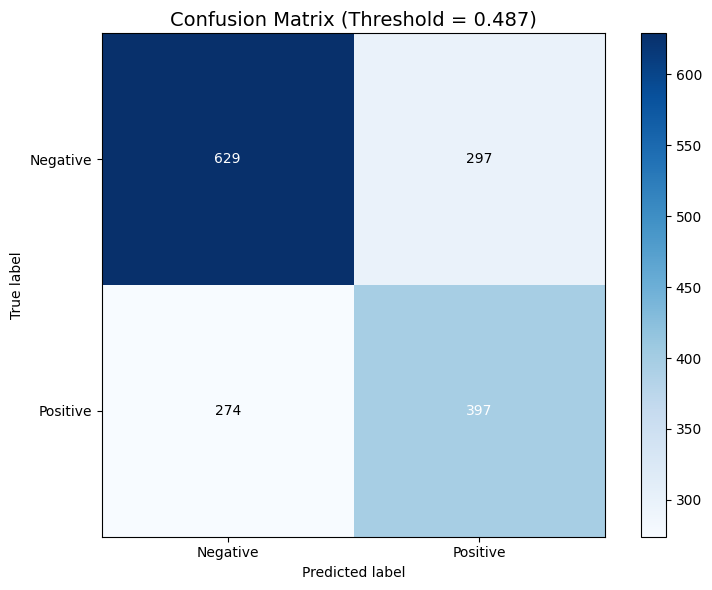

At threshold 0.487:
• Accuracy: 0.642
• Precision: 0.572
• Recall: 0.592
• F1-Score: 0.582
• True Positives: 397
• False Positives: 297
• True Negatives: 629
• False Negatives: 274

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.271 (WEAK discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.37x better than random
   Coverage: Top 30% → 44.7% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.6996 (Excellent if >0.8)
   PR-AUC: 0.6758 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.487
   Precision at threshold: 0.572
   Recall at threshold: 0.592

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                        feature  importance
175     quote_consistency_score    0.076517
224       browser_pattern_score    0.054276
152          engagement_density    0.029315
26         prefers_budget_brand    0.017969
239         price_x_consistency    0.016837
36          model_variety_score    0.015469
247                 value_score    0.015054
35

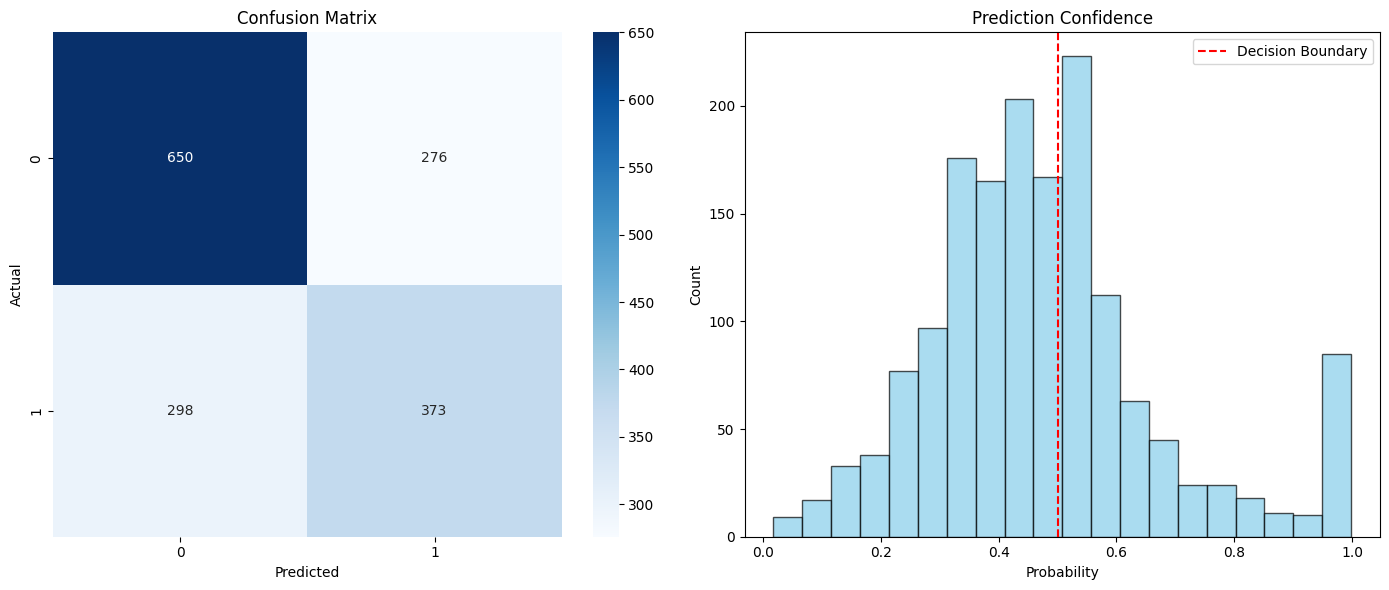

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])